In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
pd.reset_option('display.max_rows')
sns.set_style("darkgrid")  

In [136]:
all_sheets = pd.read_excel(r"c:\Users\DELL\Graduation project\Customer_Churn_Data_Large.xlsx", sheet_name=None)


In [137]:
xls = pd.ExcelFile("Customer_Churn_Data_Large.xlsx")

#sheet list
xls.sheet_names

['Customer_Demographics',
 'Transaction_History',
 'Customer_Service',
 'Online_Activity',
 'Churn_Status']

In [138]:
customer_demo = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name= "Customer_Demographics")
trans_hist = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name= "Transaction_History")
customer_service = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name= "Customer_Service")
online_activity = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name= "Online_Activity")
churn_status = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name= "Churn_Status")

Data Inspection


In [139]:
print(customer_demo.info())
print(trans_hist.info())
print(customer_service.info())
print(online_activity.info())
print(churn_status.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     1000 non-null   int64
 1   Age            1000 non-null   int64
 2   Gender         1000 non-null   str  
 3   MaritalStatus  1000 non-null   str  
 4   IncomeLevel    1000 non-null   str  
dtypes: int64(2), str(3)
memory usage: 39.2 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[us]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  5054 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 197.6 KB
None
<class 'pa

In [140]:
print("Demographics Variables", "\n",customer_demo.columns)
print("Transactional History Variables", "\n",trans_hist.columns)
print("Customer Service", "\n",customer_service.columns)
print("Online Activity", "\n",online_activity.columns)

Demographics Variables 
 Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel'], dtype='str')
Transactional History Variables 
 Index(['CustomerID', 'TransactionID', 'TransactionDate', 'AmountSpent',
       'ProductCategory'],
      dtype='str')
Customer Service 
 Index(['CustomerID', 'InteractionID', 'InteractionDate', 'InteractionType',
       'ResolutionStatus'],
      dtype='str')
Online Activity 
 Index(['CustomerID', 'LastLoginDate', 'LoginFrequency', 'ServiceUsage'], dtype='str')


EDA

In [141]:
customer_demo.head(5)

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [142]:
customer_demo.describe()

,CustomerID,Age
count,1000.000000,1000.000000
mean,500.500000,43.267000
std,288.819436,15.242311
min,1.000000,18.000000
25%,250.750000,30.000000
50%,500.500000,43.000000
75%,750.250000,56.000000
max,1000.000000,69.000000


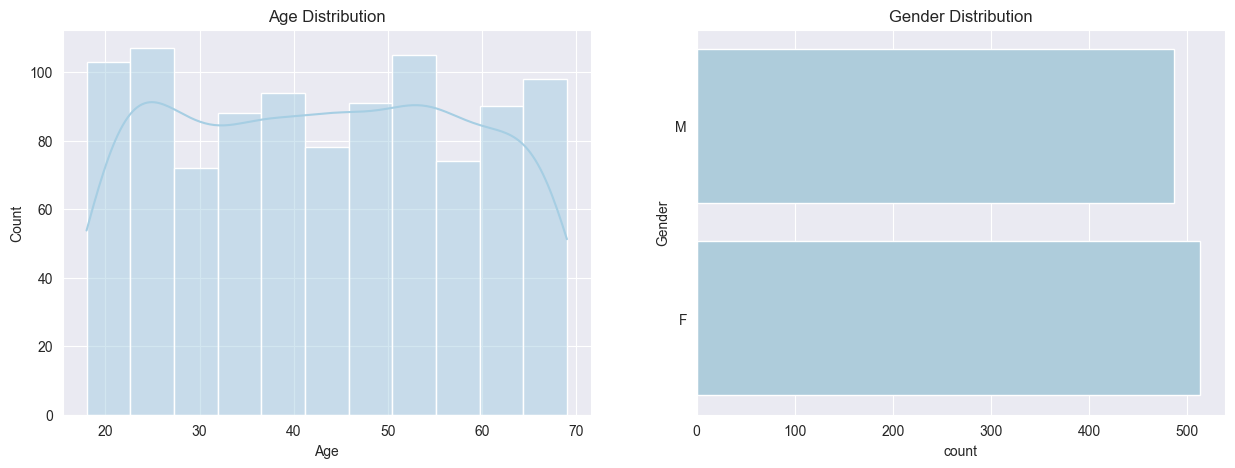

In [143]:
plt.figure(figsize=(15,5))
#kde age diagram
plt.subplot(1,2,1)
sns.histplot(data=customer_demo["Age"], kde="True")
plt.title("Age Distribution")

# Gender Barchart
plt.subplot(1,2,2)
sns.countplot(data=customer_demo["Gender"])
plt.title("Gender Distribution")
plt.show()

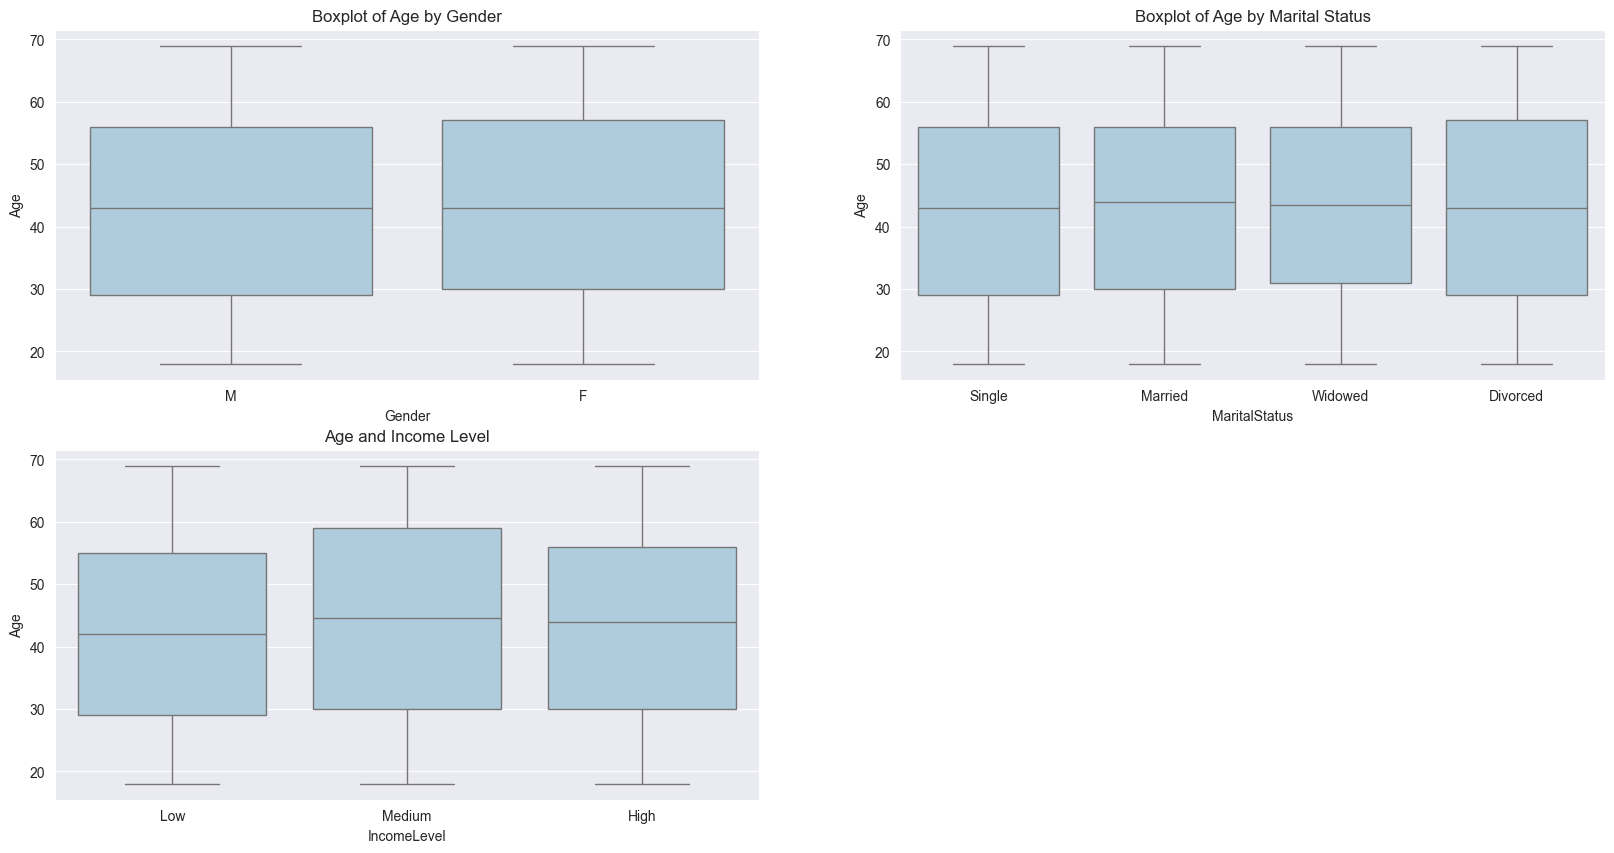

In [144]:
sns.set_palette("Paired")

plt.figure(figsize=(20, 10))
plt.subplot(2,2,1)
sns.boxplot(x='Gender', y='Age', data=customer_demo)
plt.title('Boxplot of Age by Gender')

#Age and Martial Status
plt.subplot(2,2,2)
sns.boxplot(x='MaritalStatus', y='Age', data=customer_demo)
plt.title('Boxplot of Age by Marital Status')

#Age and Income Level
plt.subplot(2,2,3)
sns.boxplot(x="IncomeLevel", y="Age", data= customer_demo)
plt.title("Age and Income Level")
plt.show()

In [145]:
trans_hist.drop(columns="TransactionID", inplace= True)
trans_hist

,CustomerID,TransactionDate,AmountSpent,ProductCategory
0,1,2022-03-27,416.50,Electronics
1,2,2022-08-08,54.96,Clothing
2,2,2022-07-25,197.50,Electronics
3,2,2022-01-25,101.31,Furniture
4,2,2022-07-24,397.37,Clothing
...,...,...,...,...
5049,1000,2022-09-08,232.06,Groceries
5050,1000,2022-12-13,324.98,Books
5051,1000,2022-06-15,375.34,Groceries
5052,1000,2022-04-08,166.73,Books


In [146]:
trans_hist.describe()

,CustomerID,TransactionDate,AmountSpent
count,5054.000000,5054,5054.000000
mean,501.424218,2022-07-01 19:25:37.158686,250.707351
min,1.000000,2022-01-01 00:00:00,5.180000
25%,251.000000,2022-04-03 00:00:00,127.105000
50%,506.000000,2022-07-01 00:00:00,250.525000
75%,749.000000,2022-09-29 00:00:00,373.412500
max,1000.000000,2022-12-31 00:00:00,499.860000
std,285.172780,NaN,142.250838


In [147]:
list(trans_hist["ProductCategory"].unique())
trans_vcount = (trans_hist["ProductCategory"].value_counts())
print(trans_vcount)

ProductCategory
Books          1041
Groceries      1020
Electronics    1001
Clothing       1000
Furniture       992
Name: count, dtype: int64


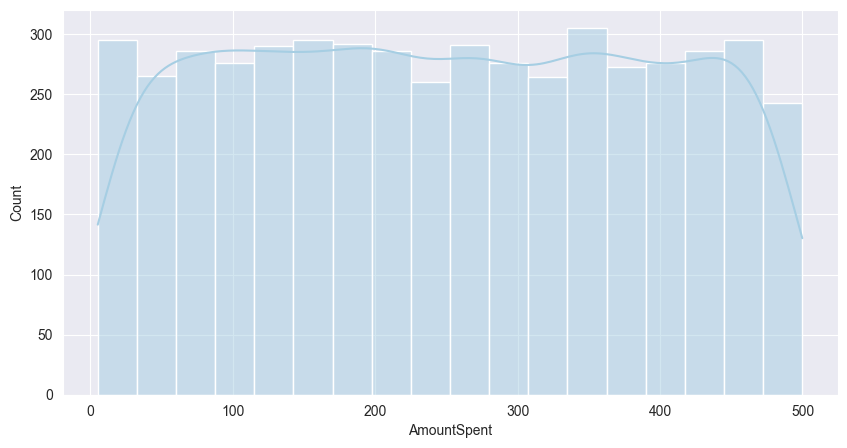

In [148]:
plt.figure(figsize=(10,5))
sns.histplot(data=trans_hist["AmountSpent"], kde=True)
plt.show()

  ProductCategory  AmountSpent
0           Books    259564.99
1        Clothing    252450.70
2     Electronics    249139.79
3       Furniture    244785.82
4       Groceries    261133.65


C:\Users\DELL\AppData\Local\Temp\ipykernel_3380\2226101870.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=amount_per_cat, x = "ProductCategory", y= "AmountSpent", marker="o", markersize = 8, linewidth = 2, legend=True, palette= "bright", markerfacecolor = "grey", markeredgecolor = "white",)


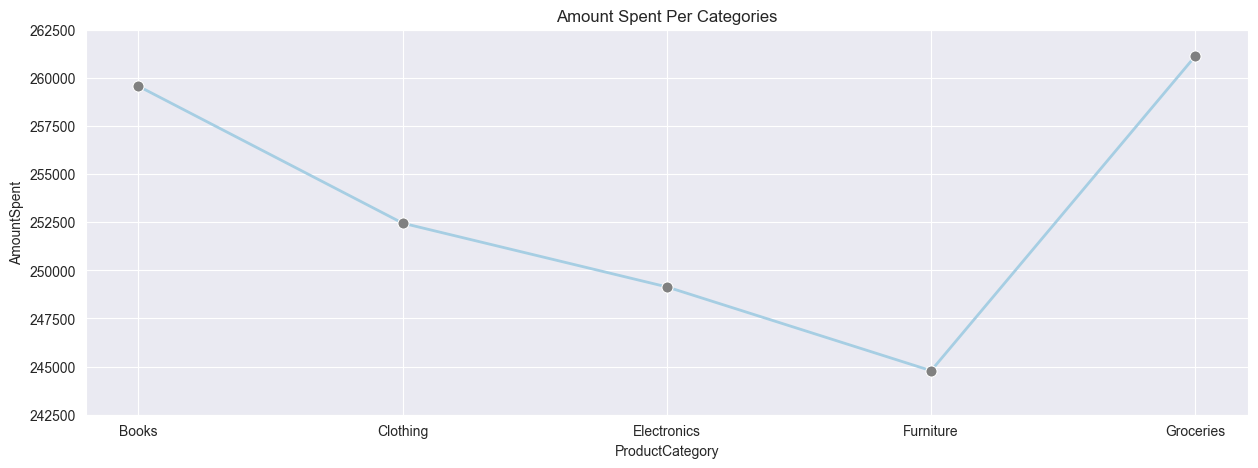

In [149]:
trans_hist["AmountSpent"].sum()
amount_per_cat = trans_hist.groupby("ProductCategory")["AmountSpent"].sum().reset_index()
print(amount_per_cat)

plt.figure(figsize= (15,5))
sns.lineplot(data=amount_per_cat, x = "ProductCategory", y= "AmountSpent", marker="o", markersize = 8, linewidth = 2, legend=True, palette= "bright", markerfacecolor = "grey", markeredgecolor = "white",)
plt.ylim(242500,262500)
plt.title("Amount Spent Per Categories")
plt.show()

(np.float64(-1.0999933036522922),
 np.float64(1.0999920678261303),
 np.float64(-1.1000000004757553),
 np.float64(1.1000000099908607))

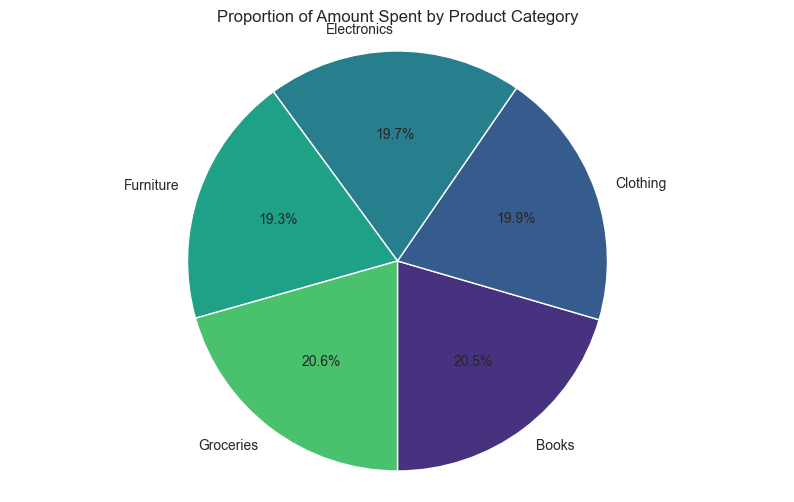

In [150]:
plt.figure(figsize=(10, 6))
plt.pie(amount_per_cat['AmountSpent'], labels=amount_per_cat['ProductCategory'], autopct='%1.1f%%', startangle=270, colors=sns.color_palette('viridis'))
plt.title('Proportion of Amount Spent by Product Category')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

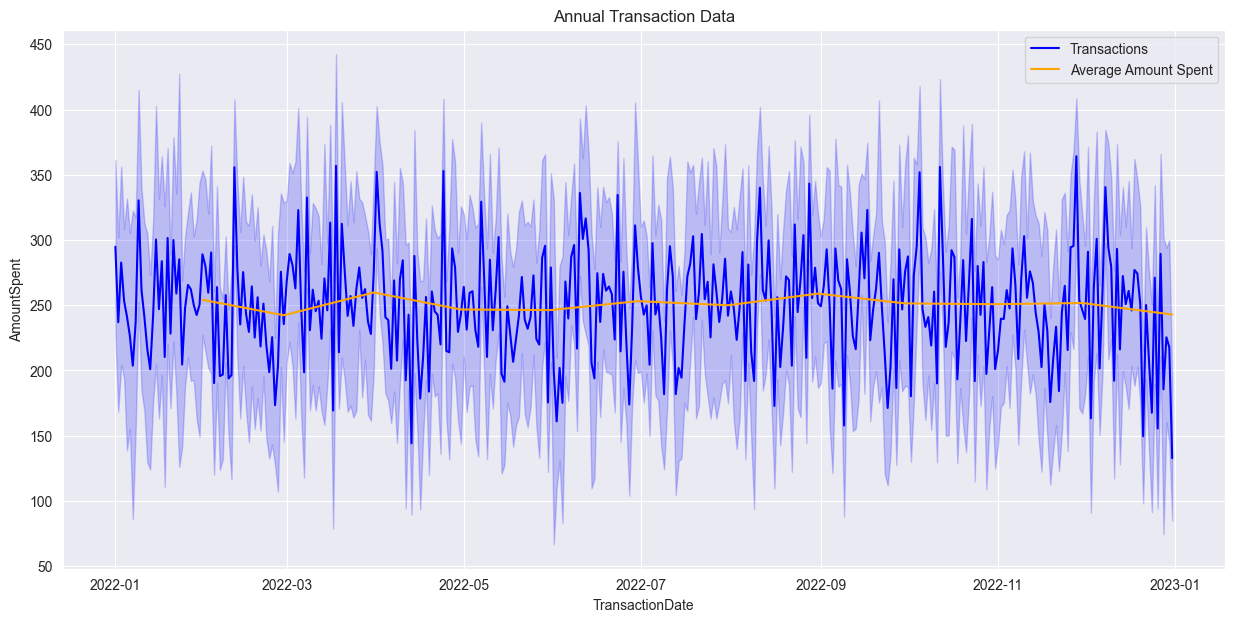

Text(0.5, 1.0, 'Annual Transaction Data')

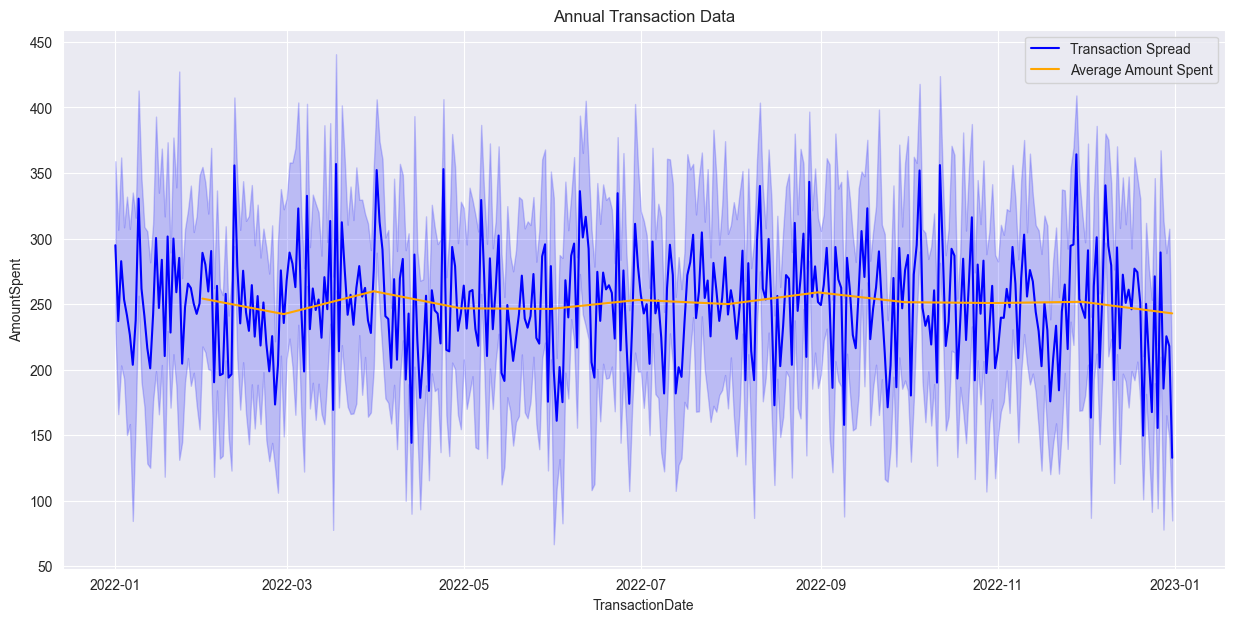

In [151]:
#trans_hist.set_index('TransactionDate', inplace=True)
# 1. تحويل عمود التاريخ لنوع datetime (خطوة ضرورية جداً)
if 'TransactionDate' in trans_hist.columns:
    trans_hist['TransactionDate'] = pd.to_datetime(trans_hist['TransactionDate'])
    trans_hist.set_index('TransactionDate', inplace=True)

# 2. الآن الـ resample سيعمل بدون أخطاء
monthly_avg = trans_hist["AmountSpent"].resample("ME").mean()
monthly_sum = trans_hist["AmountSpent"].resample("ME").sum()

# 3. الرسم البياني
plt.figure(figsize=(15, 7))

# رسم البيانات الأصلية (يومي)
sns.lineplot(x=trans_hist.index, y="AmountSpent", data=trans_hist, color="blue", label="Transactions")

# رسم المتوسط الشهري
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, color="orange", label="Average Amount Spent")

plt.title("Annual Transaction Data")
plt.show()

monthly_avg = trans_hist["AmountSpent"].resample("ME").mean()

monthly_sum = trans_hist["AmountSpent"].resample("ME").sum()


plt.figure(figsize= (15,7))
#normal data
sns.lineplot(x=trans_hist.index, y="AmountSpent", data= trans_hist, color = "blue", label = "Transaction Spread")
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, color = "orange", label = "Average Amount Spent")

plt.title("Annual Transaction Data")



<Figure size 2000x700 with 0 Axes>

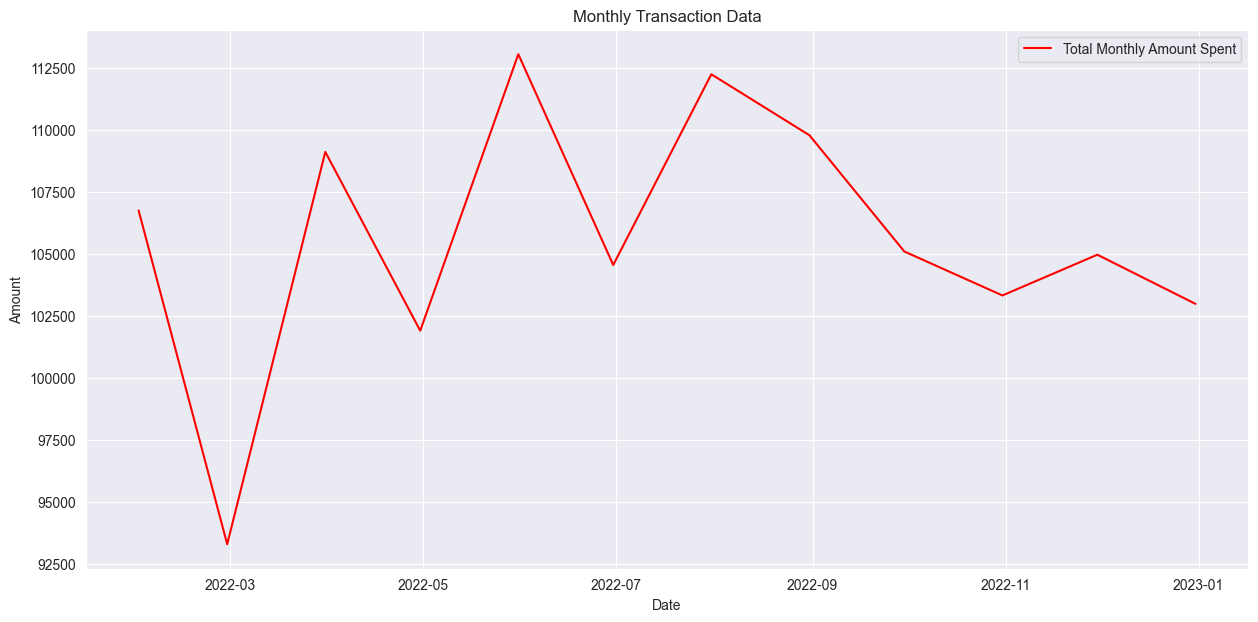

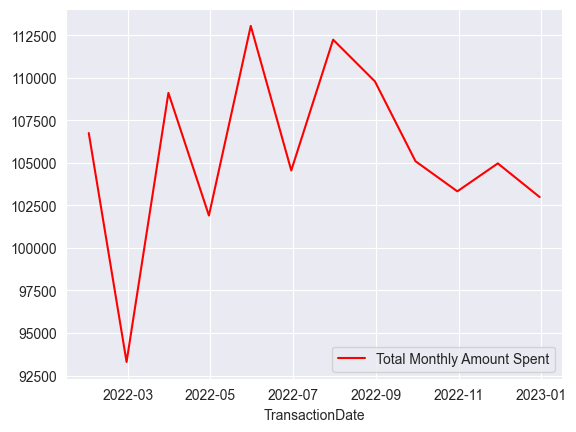

In [152]:
plt.figure(figsize= (20,7))


import matplotlib.pyplot as plt
import seaborn as sns

if 'TransactionDate' in trans_hist.columns:
    trans_hist.set_index('TransactionDate', inplace=True)

monthly_avg = trans_hist["AmountSpent"].resample("ME").mean()
monthly_sum = trans_hist["AmountSpent"].resample("ME").sum()

plt.figure(figsize=(15, 7))

sns.lineplot(x=monthly_sum.index, y=monthly_sum.values, color="red", label="Total Monthly Amount Spent")

plt.title("Monthly Transaction Data")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.show()


sns.lineplot(x=monthly_sum.index, y=monthly_sum.values, color = "red", label = "Total Monthly Amount Spent")
plt.show()

In [153]:
customer_service.drop(columns= "InteractionID", inplace= True)
customer_service.head(5)

,CustomerID,InteractionDate,InteractionType,ResolutionStatus
0,1,2022-03-31,Inquiry,Resolved
1,2,2022-03-17,Inquiry,Resolved
2,3,2022-08-24,Inquiry,Resolved
3,4,2022-11-18,Inquiry,Resolved
4,4,2022-07-03,Inquiry,Unresolved


In [154]:
import gc
print(customer_service["InteractionType"].value_counts())
print(customer_service["ResolutionStatus"].value_counts())

InteractionType
Feedback     360
Complaint    335
Inquiry      307
Name: count, dtype: int64
ResolutionStatus
Resolved      523
Unresolved    479
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_3380\2552149201.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer_service, x= "InteractionType", orient= "v", palette= "bright")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3380\2552149201.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer_service, x= "ResolutionStatus", orient="v", palette= "bright")


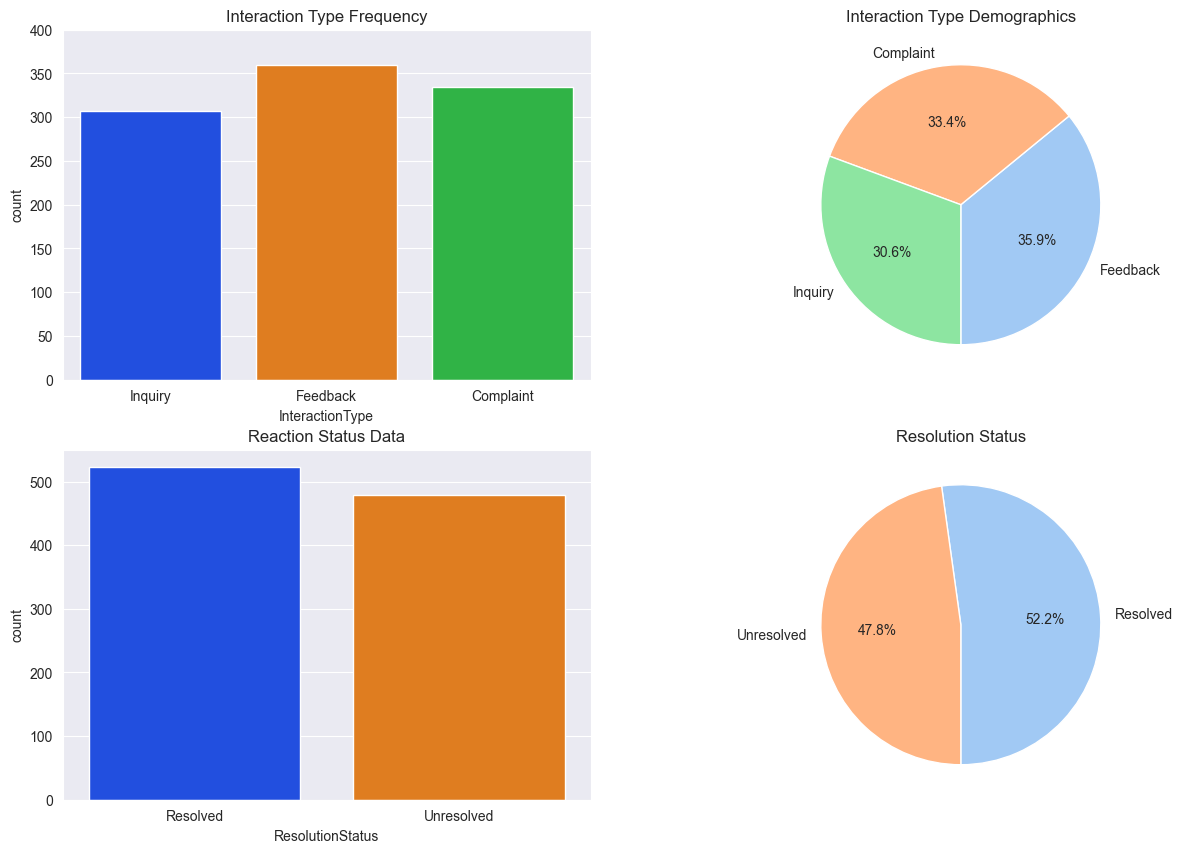

In [155]:
plt.figure(figsize= (15,10))
# **Barplot for interaction type and resolution status**

#For Interaction Type:
plt.subplot(2,2,1)
sns.countplot(data=customer_service, x= "InteractionType", orient= "v", palette= "bright")
plt.title("Interaction Type Frequency")
plt.ylim(0,400)

#For Reaction Type
plt.subplot(2,2,3)
sns.countplot(data=customer_service, x= "ResolutionStatus", orient="v", palette= "bright")
plt.title("Reaction Status Data")
plt.ylim(0,550)

# Calculate % distribution
# For Interaction Type
int_count = customer_service["InteractionType"].value_counts()
int_percent = (int_count/int_count.sum())*100
# For Resolution Type
res_count = customer_service["ResolutionStatus"].value_counts()
res_percent = (res_count/res_count.sum())*100

# Pie Chart
# For Interaction Type
plt.subplot(2,2,2)
plt.pie(int_percent, labels= int_percent.index, autopct= "%1.1f%%",startangle=270, colors=sns.color_palette('pastel'))
plt.title("Interaction Type Demographics")

#For Resolution Status
plt.subplot(2,2,4)
plt.pie(res_percent, labels=res_percent.index, autopct= "%1.1f%%", startangle=270, colors=sns.color_palette('pastel') )
plt.title("Resolution Status")


plt.show()


Online activity

In [156]:
online_activity.head(5)

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [157]:
online_activity

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website
...,...,...,...,...
995,996,2023-01-29,38,Mobile App
996,997,2023-04-01,5,Mobile App
997,998,2023-07-10,47,Website
998,999,2023-01-08,23,Website


In [158]:
service_cat = online_activity["ServiceUsage"].value_counts()
total_usage_cat = online_activity.groupby("ServiceUsage")["LoginFrequency"].sum().reset_index()
total_usage_cat

,ServiceUsage,LoginFrequency
0,Mobile App,8565
1,Online Banking,9375
2,Website,7972


C:\Users\DELL\AppData\Local\Temp\ipykernel_3380\345611661.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data= total_usage_cat, x="ServiceUsage", y="LoginFrequency", palette= "bright", ci=None)
C:\Users\DELL\AppData\Local\Temp\ipykernel_3380\345611661.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= total_usage_cat, x="ServiceUsage", y="LoginFrequency", palette= "bright", ci=None)


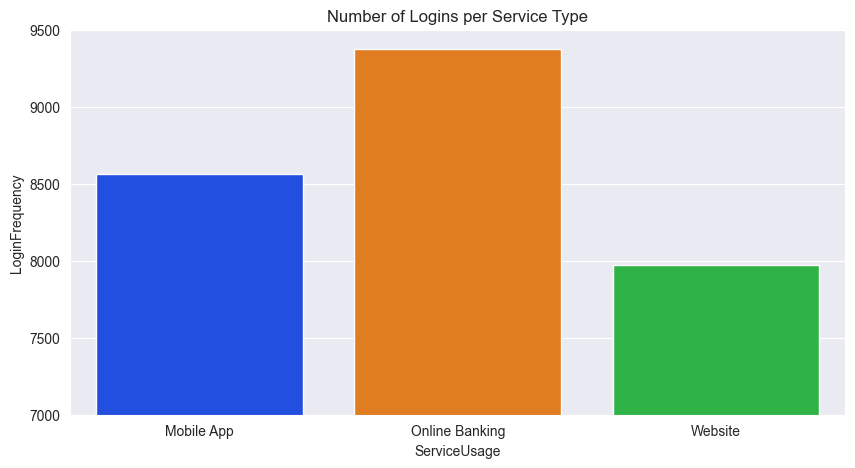

In [159]:
plt.figure(figsize=(10,5))

# Barchart LoginFreq X Service Usage
sns.barplot(data= total_usage_cat, x="ServiceUsage", y="LoginFrequency", palette= "bright", ci=None)
plt.title("Number of Logins per Service Type")
plt.ylim(7000,9500)
plt.show()

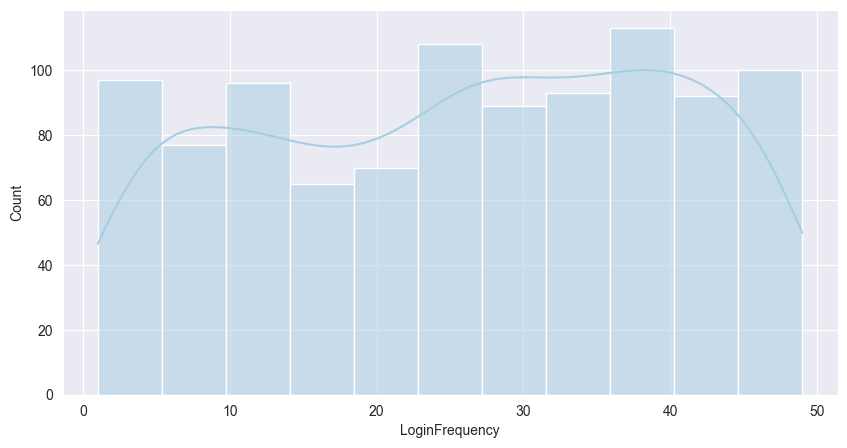

In [160]:
plt.figure(figsize=(10,5))
sns.histplot(data= online_activity["LoginFrequency"], kde=True)
plt.show()

In [161]:
#online_activity.set_index("LastLoginDate", inplace= True)
# convert to monthly
total_month = online_activity["LoginFrequency"].resample("ME").sum()
total_avg = online_activity["LoginFrequency"].resample("ME").mean()

# Create Line Plots
plt.figure(figsize=(20,7))
sns.lineplot(x = total_month.index, y = total_month.values, color = "orange")
plt.show()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

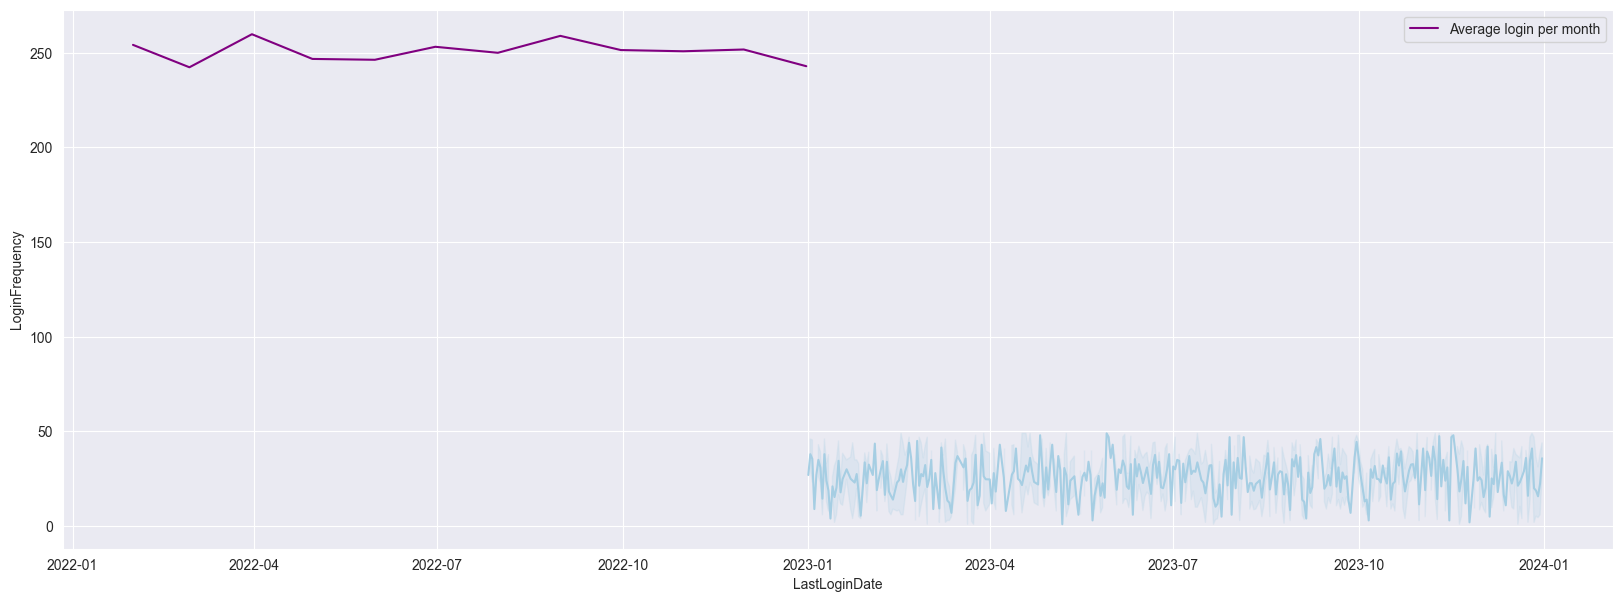

In [ ]:


plt.figure(figsize=(20, 7))

sns.lineplot(x=online_activity.index, y="LoginFrequency", data=online_activity)

sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, color="purple", label="Average login per month")

plt.show()

plt.show() 

In [ ]:
customer_demo

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium
...,...,...,...,...,...
995,996,54,F,Single,Low
996,997,19,M,Widowed,High
997,998,47,M,Married,Low
998,999,23,M,Widowed,High


In [ ]:
customer_service

,CustomerID,InteractionDate,InteractionType,ResolutionStatus
0,1,2022-03-31,Inquiry,Resolved
1,2,2022-03-17,Inquiry,Resolved
2,3,2022-08-24,Inquiry,Resolved
3,4,2022-11-18,Inquiry,Resolved
4,4,2022-07-03,Inquiry,Unresolved
...,...,...,...,...
997,990,2022-10-25,Complaint,Unresolved
998,992,2022-09-29,Feedback,Unresolved
999,994,2022-07-02,Complaint,Unresolved
1000,994,2022-05-14,Complaint,Unresolved


In [ ]:
trans_hist =trans_hist.reset_index()
online_activity = online_activity.reset_index()
print("Dataset Shape", "\n")
print("transaction history:","",trans_hist.shape)
print("customer demo:","",customer_demo.shape)
print("customer service:","",customer_service.shape)
print("online activity:","",online_activity.shape)
print("churn staturs:","",churn_status.shape)

Dataset Shape 

transaction history:  (5054, 4)
customer demo:  (1000, 5)
customer service:  (1002, 4)
online activity:  (1000, 4)
churn staturs:  (1000, 2)


In [ ]:
print("Demographics Variables", "\n",customer_demo.columns)
print("Transactional History Variables", "\n",trans_hist.columns)
print("Customer Service", "\n",customer_service.columns)
print("Online Activity", "\n",online_activity.columns)
print("Churn Status", "\n",churn_status.columns)

Demographics Variables 
 Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel'], dtype='str')
Transactional History Variables 
 Index(['TransactionDate', 'CustomerID', 'AmountSpent', 'ProductCategory'], dtype='str')
Customer Service 
 Index(['CustomerID', 'InteractionDate', 'InteractionType', 'ResolutionStatus'], dtype='str')
Online Activity 
 Index(['LastLoginDate', 'CustomerID', 'LoginFrequency', 'ServiceUsage'], dtype='str')
Churn Status 
 Index(['CustomerID', 'ChurnStatus'], dtype='str')


In [ ]:
print(trans_hist.isnull().sum(),"\n")
print(customer_demo.isnull().sum(),"\n")
print(customer_service.isnull().sum(),"\n")
print(online_activity.isnull().sum(),"\n")
print(churn_status.isnull().sum(),"\n")

TransactionDate    0
CustomerID         0
AmountSpent        0
ProductCategory    0
dtype: int64 

CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64 

CustomerID          0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
dtype: int64 

LastLoginDate     0
CustomerID        0
LoginFrequency    0
ServiceUsage      0
dtype: int64 

CustomerID     0
ChurnStatus    0
dtype: int64 



In [ ]:
merge_df = customer_demo.merge(trans_hist, on="CustomerID", how="left")
merge_df = merge_df.merge(customer_service, on= "CustomerID", how= "left")
merge_df = merge_df.merge(online_activity, on= "CustomerID", how="left")
merge_df = merge_df.merge(churn_status, on = "CustomerID", how= "left")
merge_df

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionDate,AmountSpent,ProductCategory,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,2022-03-27,416.50,Electronics,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,2022-08-08,54.96,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,2022-07-25,197.50,Electronics,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2022-01-25,101.31,Furniture,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,2022-07-24,397.37,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,1000,34,M,Widowed,Low,2022-09-08,232.06,Groceries,NaT,NaN,NaN,2023-08-13,22,Mobile App,0
6808,1000,34,M,Widowed,Low,2022-12-13,324.98,Books,NaT,NaN,NaN,2023-08-13,22,Mobile App,0
6809,1000,34,M,Widowed,Low,2022-06-15,375.34,Groceries,NaT,NaN,NaN,2023-08-13,22,Mobile App,0
6810,1000,34,M,Widowed,Low,2022-04-08,166.73,Books,NaT,NaN,NaN,2023-08-13,22,Mobile App,0


In [ ]:
null_values = merge_df[merge_df.isnull()]
null_values

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionDate,AmountSpent,ProductCategory,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN
6808,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN
6809,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN
6810,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN


In [ ]:
print(trans_hist.head(10))

  TransactionDate  CustomerID  AmountSpent ProductCategory
0      2022-03-27           1       416.50     Electronics
1      2022-08-08           2        54.96        Clothing
2      2022-07-25           2       197.50     Electronics
3      2022-01-25           2       101.31       Furniture
4      2022-07-24           2       397.37        Clothing
5      2022-01-09           2       285.21     Electronics
6      2022-09-16           2       311.34     Electronics
7      2022-11-19           2       199.73       Groceries
8      2022-10-08           3       241.06           Books
9      2022-08-15           3        51.07        Clothing


In [ ]:
agg_trans_hist = trans_hist.groupby("CustomerID").agg({"AmountSpent":"sum","TransactionDate":"count"}).reset_index()
agg_trans_hist.rename(columns={"Transactional Data" :"TransactionFreq"}, inplace=True)
agg_trans_hist.isnull().sum()

CustomerID         0
AmountSpent        0
TransactionDate    0
dtype: int64

In [ ]:
cleaned_df = customer_demo.merge(agg_trans_hist, on="CustomerID", how="left")
#cleaned_df = cleaned_df.merge(customer_service, on= "CustomerID", how= "left")
cleaned_df = cleaned_df.merge(online_activity, on= "CustomerID", how="left")
cleaned_df = cleaned_df.merge(churn_status, on = "CustomerID", how= "left")
cleaned_df

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,AmountSpent,TransactionDate,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,416.50,1,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,1547.42,7,2023-12-05,5,Website,1
2,3,18,M,Single,Low,1702.98,6,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,917.29,5,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,2001.49,8,2023-10-27,41,Website,0
...,...,...,...,...,...,...,...,...,...,...,...
995,996,54,F,Single,Low,227.25,1,2023-01-29,38,Mobile App,0
996,997,19,M,Widowed,High,419.82,2,2023-04-01,5,Mobile App,0
997,998,47,M,Married,Low,252.15,1,2023-07-10,47,Website,0
998,999,23,M,Widowed,High,2393.26,9,2023-01-08,23,Website,0


In [ ]:
customer_service.shape

(1002, 4)

In [ ]:
customer_service

,CustomerID,InteractionDate,InteractionType,ResolutionStatus
0,1,2022-03-31,Inquiry,Resolved
1,2,2022-03-17,Inquiry,Resolved
2,3,2022-08-24,Inquiry,Resolved
3,4,2022-11-18,Inquiry,Resolved
4,4,2022-07-03,Inquiry,Unresolved
...,...,...,...,...
997,990,2022-10-25,Complaint,Unresolved
998,992,2022-09-29,Feedback,Unresolved
999,994,2022-07-02,Complaint,Unresolved
1000,994,2022-05-14,Complaint,Unresolved


In [ ]:
gc.collect()
23595
#duplicated_cs =customer_service[customer_service.duplicated()]

#duplicated_cs

23595

In [ ]:
# Aggregate data
agg_cs_df = customer_service.groupby('CustomerID').agg(
    InteractionCount=('CustomerID', 'size'),
    LastInteraction=('InteractionDate', 'max'),
    ComplaintCount=('InteractionType', lambda x: (x == 'Complaint').sum()),
    FeedbackCount=('InteractionType', lambda x: (x == 'Feedback').sum()),
    InquiryCount=('InteractionType', lambda x: (x == 'Inquiry').sum()),
    ResolvedCount=('ResolutionStatus', lambda x: (x == 'Resolved').sum()),
    UnresolvedCount=('ResolutionStatus', lambda x: (x == 'Unresolved').sum())
).reset_index()
agg_cs_df

,CustomerID,InteractionCount,LastInteraction,ComplaintCount,FeedbackCount,InquiryCount,ResolvedCount,UnresolvedCount
0,1,1,2022-03-31,0,0,1,1,0
1,2,1,2022-03-17,0,0,1,1,0
2,3,1,2022-08-24,0,0,1,1,0
3,4,2,2022-11-18,0,0,2,1,1
4,6,1,2022-05-05,0,1,0,1,0
...,...,...,...,...,...,...,...,...
663,989,2,2022-10-07,2,0,0,0,2
664,990,2,2022-10-25,1,1,0,1,1
665,992,1,2022-09-29,0,1,0,0,1
666,994,2,2022-07-02,2,0,0,0,2


In [ ]:
cleaned_df = cleaned_df.merge(agg_cs_df, on="CustomerID", how="left")
cleaned_df

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,AmountSpent,TransactionDate,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,InteractionCount,LastInteraction,ComplaintCount,FeedbackCount,InquiryCount,ResolvedCount,UnresolvedCount
0,1,62,M,Single,Low,416.50,1,2023-10-21,34,Mobile App,0,1.0,2022-03-31,0.0,0.0,1.0,1.0,0.0
1,2,65,M,Married,Low,1547.42,7,2023-12-05,5,Website,1,1.0,2022-03-17,0.0,0.0,1.0,1.0,0.0
2,3,18,M,Single,Low,1702.98,6,2023-11-15,3,Website,0,1.0,2022-08-24,0.0,0.0,1.0,1.0,0.0
3,4,21,M,Widowed,Low,917.29,5,2023-08-25,2,Website,0,2.0,2022-11-18,0.0,0.0,2.0,1.0,1.0
4,5,21,M,Divorced,Medium,2001.49,8,2023-10-27,41,Website,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,54,F,Single,Low,227.25,1,2023-01-29,38,Mobile App,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN
996,997,19,M,Widowed,High,419.82,2,2023-04-01,5,Mobile App,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN
997,998,47,M,Married,Low,252.15,1,2023-07-10,47,Website,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN
998,999,23,M,Widowed,High,2393.26,9,2023-01-08,23,Website,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [ ]:

cleaned_df.to_csv(index=False)

'CustomerID,Age,Gender,MaritalStatus,IncomeLevel,AmountSpent,TransactionDate,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,InteractionCount,LastInteraction,ComplaintCount,FeedbackCount,InquiryCount,ResolvedCount,UnresolvedCount\r\n1,62,M,Single,Low,416.5,1,2023-10-21,34,Mobile App,0,1.0,2022-03-31,0.0,0.0,1.0,1.0,0.0\r\n2,65,M,Married,Low,1547.4199999999998,7,2023-12-05,5,Website,1,1.0,2022-03-17,0.0,0.0,1.0,1.0,0.0\r\n3,18,M,Single,Low,1702.98,6,2023-11-15,3,Website,0,1.0,2022-08-24,0.0,0.0,1.0,1.0,0.0\r\n4,21,M,Widowed,Low,917.29,5,2023-08-25,2,Website,0,2.0,2022-11-18,0.0,0.0,2.0,1.0,1.0\r\n5,21,M,Divorced,Medium,2001.49,8,2023-10-27,41,Website,0,,,,,,,\r\n6,57,F,Divorced,Medium,1164.29,5,2023-09-17,2,Website,0,1.0,2022-05-05,0.0,1.0,0.0,1.0,0.0\r\n7,27,F,Married,High,86.73,1,2023-01-07,32,Mobile App,0,,,,,,,\r\n8,37,M,Single,Low,2046.88,7,2023-04-22,17,Online Banking,1,2.0,2022-09-13,0.0,1.0,1.0,0.0,2.0\r\n9,39,M,Divorced,High,1317.24,5,2023-06-27,24,Website,0,1.0,2022-08-1

In [ ]:
cleaned_df.duplicated().sum()


np.int64(0)

In [ ]:
import pandas as pd
import os

file_path = r"C:\Users\DELL\Graduation project\Customer_Churn_Data_Large.xlsx"
all_sheets = pd.read_excel(file_path, sheet_name=None)

sheets_names = list(all_sheets.keys())
df = all_sheets[sheets_names[0]]

for name in sheets_names[1:]:
    df = pd.merge(df, all_sheets[name], on="CustomerID", how="outer")

print(f"Total columns after merging: {len(df.columns)}")

df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

df.drop_duplicates(inplace=True)

if "amountspent" in df.columns:
    df["amountspent"] = pd.to_numeric(df["amountspent"], errors='coerce')
    df["amountspent"] = df["amountspent"].fillna(df["amountspent"].mean())
    q_limit = df["amountspent"].quantile(0.99)
    df = df[df["amountspent"] < q_limit]

output_path = r"C:\Users\DELL\Desktop\cleaned_customer_data.csv"
df.to_csv(output_path, index=False)

print("\nSuccess! Data cleaned and saved at:", output_path)
print(df.info())
df = pd.read_excel(r"C:\Users\DELL\Graduation project\Customer_Churn_Data_Large.xlsx")

path = r"C:\Users\DELL\Desktop\cleaned_df.csv"
df.to_csv(path, index=False)



Total columns after merging: 17

Success! Data cleaned and saved at: C:\Users\DELL\Desktop\cleaned_customer_data.csv
<class 'pandas.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        6812 non-null   int64         
 1   Age               6812 non-null   int64         
 2   Gender            6812 non-null   str           
 3   MaritalStatus     6812 non-null   str           
 4   IncomeLevel       6812 non-null   str           
 5   TransactionID     6812 non-null   int64         
 6   TransactionDate   6812 non-null   datetime64[us]
 7   AmountSpent       6812 non-null   float64       
 8   ProductCategory   6812 non-null   str           
 9   InteractionID     6812 non-null   float64       
 10  InteractionDate   5204 non-null   datetime64[us]
 11  InteractionType   6812 non-null   str           
 12  ResolutionStatus  6812 non

C:\Users\DELL\AppData\Local\Temp\ipykernel_3380\1084143337.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
C:\Users\DELL\AppData\Local\Temp\ipykernel_3380\1084143337.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi